### note
from v0 (deleted, incorrect hidden state encoding)<br/>
sine, dampling testing

In [1]:
# import libraries 
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader

import numpy as np
import time
import copy

import pennylane as qml
import matplotlib.pyplot as plt

import pickle

In [2]:
class QGRUCirc:
    def __call__(self, inputs, weights):
        # inputs: includes type, inputs and hiddens
        
        # type: 0: without H ending; 1: with H ending
        H_ending = inputs[0] == 1
        # inputs
        qml.RX(inputs[1]*weights[0]+weights[1], wires=0)
        # initialize hidden state
        qml.RX(torch.arcsin(inputs[2])*weights[2]+weights[3], wires=1)
        qml.RX(torch.arcsin(inputs[3])*weights[4]+weights[5], wires=2)
        qml.RX(torch.arcsin(inputs[4])*weights[6]+weights[7], wires=3)
        qml.RX(torch.arcsin(inputs[5])*weights[8]+weights[9], wires=4)
        qml.RY(torch.arcsin(inputs[6])*weights[10]+weights[11], wires=1)
        qml.RY(torch.arcsin(inputs[7])*weights[12]+weights[13], wires=2)
        qml.RY(torch.arcsin(inputs[8])*weights[14]+weights[15], wires=3)
        qml.RY(torch.arcsin(inputs[9])*weights[16]+weights[17], wires=4)
        qml.CNOT(wires=[1, 2])
        qml.CNOT(wires=[2, 3])
        qml.CNOT(wires=[3, 4])
        qml.Barrier(wires=range(5))
        # gates
        qml.CNOT(wires=[0, 1])
#         qml.CSWAP(wires=[1, 2, 5])
        qml.CNOT(wires=[1, 2])
        qml.RX(weights[18], wires=1)
#         qml.CSWAP(wires=[1, 4, 6])
        qml.CNOT(wires=[1, 4])
        qml.Barrier(wires=range(5))
        # layer 1
        qml.RX(weights[19], wires=0)
        qml.RX(weights[20], wires=1)
        qml.RX(weights[21], wires=2)
        qml.RX(weights[22], wires=3)
        qml.RX(weights[23], wires=4)
        qml.CNOT(wires=[4, 3])
        qml.CNOT(wires=[3, 2])
        qml.CNOT(wires=[2, 1])
        qml.CNOT(wires=[1, 0])
        qml.Barrier(wires=range(5))
        # layer 2
        qml.RY(weights[24], wires=0)
        qml.RY(weights[25], wires=1)
        qml.RY(weights[26], wires=2)
        qml.RY(weights[27], wires=3)
        qml.RY(weights[28], wires=4)
        qml.CNOT(wires=[4, 3])
        qml.CNOT(wires=[3, 2])
        qml.CNOT(wires=[2, 1])
        qml.CNOT(wires=[1, 0])
        
        # ending
        if H_ending:
            qml.Hadamard(wires=[1])
            qml.Hadamard(wires=[2])
            qml.Hadamard(wires=[3])
            qml.Hadamard(wires=[4])
        
        return [qml.expval(qml.PauliZ(i)) for i in range(5)]
        

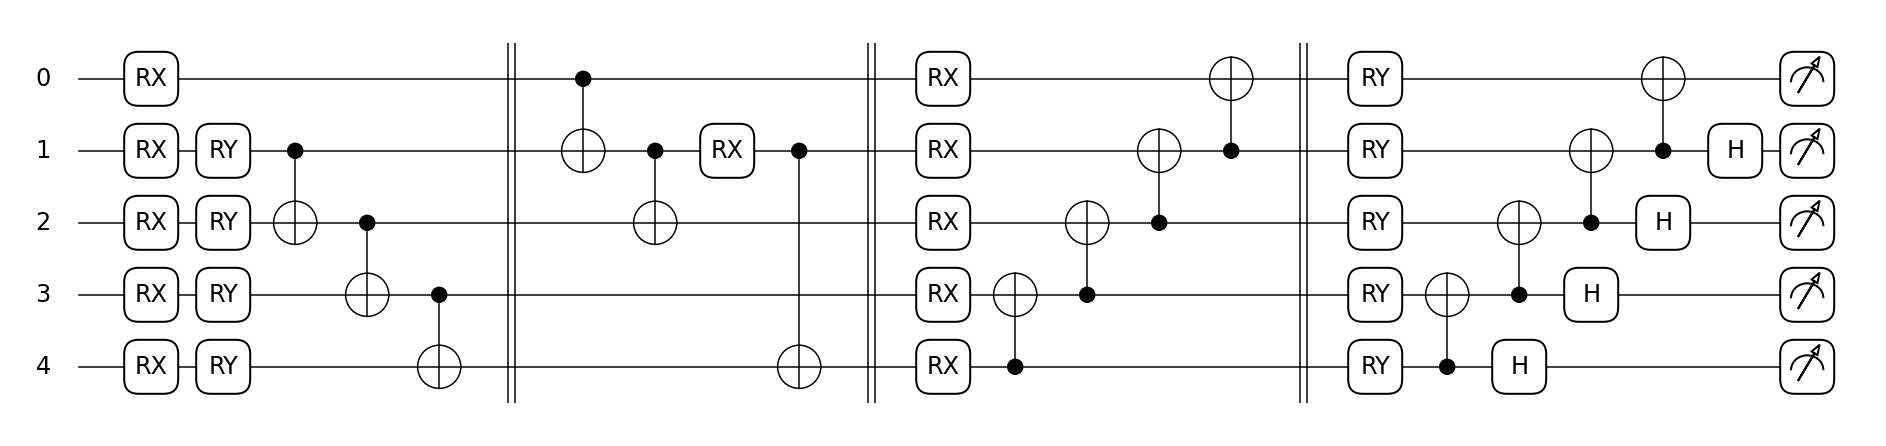

In [3]:
# https://pennylane.readthedocs.io/en/stable/code/api/pennylane.draw_mpl.html

qml.drawer.use_style('black_white')
dev = qml.device("default.qubit", wires=8)
qcirc = QGRUCirc()
qnode = qml.QNode(qcirc, dev)

fig, _ = qml.draw_mpl(qnode, fontsize=24)(torch.cat((torch.tensor([1]),torch.rand(10)),0),range(29))

In [4]:
#class QNode(func, device, interface='autograd', diff_method='best', mutable=True,
#max_expansion=10, h=1e-07, order=1, shift=1.5707963267948966, adjoint_cache=True, argnum=None, **kwargs)

class QGRU(nn.Module):
    def __init__(self):
        super(QGRU, self).__init__()
        
        dev = qml.device("default.qubit", wires=7)
        circuit = QGRUCirc()
        qnode = qml.QNode(circuit, dev)
        
        self.weight_shapes = {"weights": 29}
        self.qgru = qml.qnn.TorchLayer(qnode, self.weight_shapes)
        self.hidden_size = 4*2
                
    def forward(self, inputs, hiddens=None):
        # Currently, input dim=1, hidden dim=4x2
        in_dim = 1
        
        single = len(inputs.size()) == 1
        if single:
            inputs = torch.unsqueeze(inputs, 0)
        
#         if len(inputs.size()) == 1:
#             if hiddens == None:
#                 hiddens = torch.zeros(self.hidden_size)
#             Xs1 = torch.cat((torch.zeros(1), inputs, hiddens))
#             Xs2 = torch.cat((torch.ones(1), inputs, hiddens))
#         else:
            
            
        if hiddens == None:
            hiddens = torch.zeros([inputs.size(0), self.hidden_size])
        Xs1 = torch.cat((torch.zeros([inputs.size(0), 1]), inputs, hiddens), 1)
        Xs2 = torch.cat((torch.ones([inputs.size(0), 1]), inputs, hiddens), 1)
            
        Ys1 = self.qgru(Xs1)
        Ys2 = self.qgru(Xs2)
        
        outputs = (Ys1[:,0:in_dim] + Ys2[:,0:in_dim]) / 2
        Hs1 = Ys1[:, in_dim:]
        Hs2 = Ys2[:, in_dim:]
        
        Ys = torch.cat((outputs, Hs1, Hs2), 1)
        
        if single:
            Ys = Ys[0]
            
        return Ys # Currently, output dim=5
    

## Sequence (to make a RNN)

In [5]:
class Sequence(nn.Module):
    def __init__(self, initial_weight=None):
        super(Sequence, self).__init__()
        
        self.qgru = QGRU()
        self.out_size = 1
#         self.h_0 = torch.zeros(self.qgru.num_of_hidden)

    def forward(self, inputs, future = 0):
        # inputs: tensor
        # [[a1, a2, a3, ...]...] or [[[a1, a2, a3, ...]...]...]
        
        single = len(inputs.size()) == 2
        
        if single:
            inputs = torch.unsqueeze(inputs, 0)
        
        ht = None
        outSeq = torch.tensor([])
        
        for Xs in torch.transpose(inputs, 0, 1):
            Ys = self.qgru(Xs, ht)
            outs = Ys[:, :self.out_size]
            ht = Ys[:, self.out_size:]
            outSeq = torch.cat((outSeq, torch.unsqueeze(outs, 1)), 1)
            
        # future: only for the same types of input and output
        # the last outputs are used fot next inputs
        for _ in range(future):
            Ys = self.qgru(outs, ht)
            outs = Ys[:, :self.out_size]
            ht = Ys[:, self.out_size:]
            outSeq = torch.cat((outSeq, torch.unsqueeze(outs, 1)), 1)
            
        if single:
            outSeq = outSeq[0]
            
        return outSeq
   

## Sine

In [ ]:
sine = ((torch.tensor([np.sin(_*0.4) for _ in range(151)])*0.5)).float()
sineInput = sine[:-51]
sineTarget = sine[1:len(sineInput)+1]

sineInput = sineInput.reshape([len(sineInput),1])
sineTarget = sineTarget.reshape([len(sineTarget),1])

sineInput_a = sine[:-1]
sineInput_a = sineInput_a.reshape([len(sineInput_a),1])

plt.scatter(range(len(sine)), sine, s=3)
plt.ylim(-1,1)
plt.show()

In [ ]:
np.random.seed(0)
torch.manual_seed(0)
model = Sequence()

start_time = time.time()
criterion = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
minLoss = 100000
lossList = []

for t in range(1000):
    prediction = model.forward(sineInput)
    
    # Compute and print loss
    loss = criterion(prediction, sineTarget)
    if loss.item() <= minLoss:
        minLoss = loss.item()
        best_state = copy.deepcopy(model.state_dict())

    curtime = time.time()
    print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time), end='\r')
    if t % 10 == 9:
        print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time))
        lossList.append(loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [ ]:
plt.plot([x*10 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

In [ ]:
best_model = Sequence()
best_model.load_state_dict(best_state)
bestPredict = best_model(sineInput, 50).detach()

In [ ]:
bp = bestPredict.tolist()
ta = sineTarget.tolist()
tb = sine[len(sineInput)+1:].tolist()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

## Damping

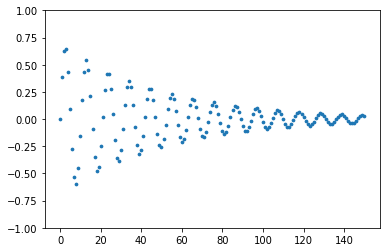

In [6]:
damp = ((torch.tensor([np.sin(_*0.6)*np.exp(_*-0.02) for _ in range(151)])*0.7)).float()
dampInput = damp[:-51]
dampTarget = damp[1:len(dampInput)+1]

dampInput = dampInput.reshape([len(dampInput),1])
dampTarget = dampTarget.reshape([len(dampTarget),1])

dampInput_a = damp[:-1]
dampInput_a = dampInput_a.reshape([len(dampInput_a),1])

plt.scatter(range(len(damp)), damp, s=3)
plt.ylim(-1,1)
plt.show()

In [18]:
np.random.seed(3)
torch.manual_seed(3)
model = Sequence()

start_time = time.time()
criterion = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
minLoss = 100000
lossList = []

for t in range(1000):
    prediction = model.forward(dampInput)
    
    # Compute and print loss
    loss = criterion(prediction, dampTarget)
    if loss.item() <= minLoss:
        minLoss = loss.item()
        best_state = copy.deepcopy(model.state_dict())

    curtime = time.time()
    print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time), end='\r')
    if t % 10 == 9:
        print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time))
        lossList.append(loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

9: 0.06223874166607857  54.33887791633606         
19: 0.06125541031360626  110.65853118896484        
29: 0.06065826117992401  162.4508922100067         
39: 0.059739671647548676  214.77118968963623       
49: 0.05940743535757065  269.3017113208771         
59: 0.05869435891509056  324.66967129707336       
69: 0.05602617189288139  377.79736948013306        
79: 0.05051320046186447  430.1027867794037         
89: 0.04271497204899788  485.63376688957214        
99: 0.03518134355545044  544.1462376117706        
109: 0.028534142300486565  636.3876988887787       
119: 0.024723829701542854  693.7571678161621       
129: 0.020609140396118164  748.5546667575836       
139: 0.016944551840424538  805.5252108573914       
149: 0.014864271506667137  873.0749237537384       
159: 0.013680625706911087  927.5817325115204       
169: 0.012974978424608707  986.8682298660278       
179: 0.01239487249404192  1045.7630875110626        
189: 0.011963878758251667  1573.464949131012        
199: 0.011636

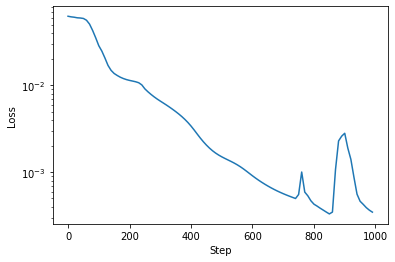

In [19]:
plt.plot([x*10 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

In [20]:
best_model = Sequence()
best_model.load_state_dict(best_state)
bestPredict = best_model(dampInput, 50).detach()

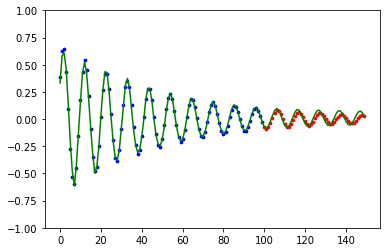

In [21]:
bp = bestPredict.tolist()
ta = dampTarget.tolist()
tb = damp[len(dampInput)+1:].tolist()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

### all data

In [ ]:
allInput = torch.cat((torch.unsqueeze(sineInput, 0), torch.unsqueeze(sineInput, 0)))
allTarget = torch.cat((torch.unsqueeze(dampTarget, 0), torch.unsqueeze(dampTarget, 0)))

## Batch loader

In [ ]:
class MyDataset(Dataset):

    # data loading
    def __init__(self, xs, ys):
        self.x = xs
        self.y = ys
        self.n_samples = len(xs)

    # working for indexing
    def __getitem__(self, index):
        
        return self.x[index], self.y[index]

    # return the length of our dataset
    def __len__(self):
        
        return self.n_samples

In [ ]:
dataset = MyDataset(allInput, allTarget)
dataloader = DataLoader(dataset=dataset, batch_size=2, shuffle=True)

In [ ]:
seed = np.random.randint(1000)
seed

In [ ]:
np.random.seed(0)
torch.manual_seed(0)
model = Sequence()

start_time = time.time()
criterion = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
minLoss = 100000
lossList = []

for epoch in range(500):
    loss_total = 0.0
    n = 0
    for inpSeqC, testTargetC in dataloader:
        n += 1
        
        prediction = model.forward(inpSeqC)

        # Compute and print loss
        loss = criterion(prediction, testTargetC)
        loss_total += loss.item()

        curtime = time.time()
        print('{}, {}: {}  {}       '.format(epoch, n, loss.item(), curtime-start_time), end='\r')

        # Zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    loss_avg = loss_total / n # loss per batch
    if epoch % 10 == 9:
        print('{}, avg.: {}  {}       '.format(epoch, loss_avg, curtime-start_time))
        lossList.append(loss_avg)
        
    if loss_avg <= minLoss:
        minLoss = loss_avg
        best_state = copy.deepcopy(model.state_dict())

In [ ]:
plt.clf()
plt.plot([x*10 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

In [ ]:
best_model = Sequence()
best_model.load_state_dict(best_state)

In [ ]:
bestPredict = best_model(sineInput, 50).detach()

In [ ]:
bp = bestPredict.tolist()
ta = sineTarget.tolist()
tb = sine[len(sineInput)+1:].tolist()
plt.clf()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

In [7]:
seeds = [np.random.randint(0, 1000) for _ in range(10)]
seeds = [847, 288, 794, 108, 945, 471, 300, 813, 359, 445]
seeds

[847, 288, 794, 108, 945, 471, 300, 813, 359, 445]

In [8]:
def damping_test(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    model = Sequence()

    start_time = time.time()
    criterion = torch.nn.MSELoss(reduction='mean')
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    minLoss = 100000
    lossList = []

    for t in range(1000):
        prediction = model.forward(dampInput)

        # Compute and print loss
        loss = criterion(prediction, dampTarget)
        if loss.item() <= minLoss:
            minLoss = loss.item()
            best_state = copy.deepcopy(model.state_dict())

        curtime = time.time()
        print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time), end='\r')
        if t % 10 == 9:
            print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time))
            lossList.append(loss.item())

        # Zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    return lossList, best_state

In [ ]:
aa = test(847)

In [ ]:
loss = aa[0]
bState = aa[1]

In [ ]:
plt.clf()
plt.plot([x*10 for x in range(len(loss))], loss)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

In [ ]:
best_model = Sequence()
best_model.load_state_dict(bState)
bestPredict = best_model(testInput, 50).detach()

bp = bestPredict.tolist()
ta = testTarget.tolist()
tb = ys[len(testInput)+1:].tolist()
plt.clf()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

In [9]:
def plotPNG(seed, loss, bState):
    plt.clf()
    plt.plot([x*10 for x in range(len(loss))], loss)
    plt.ylabel('Loss')
    plt.xlabel('Step')
    plt.yscale("log")
    plt.savefig('loss_' + str(seed) + '.png')
    
    best_model = Sequence()
    best_model.load_state_dict(bState)
    bestPredict = best_model(dampInput, 50).detach()
    
    bp = bestPredict.tolist()
    ta = dampTarget.tolist()
    tb = damp[len(dampInput)+1:].tolist()
    plt.clf()
    plt.scatter(range(len(ta)), ta, c='b', s=3)
    plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
    plt.plot(bp, c='g')
    plt.ylim(-1,1)
    plt.savefig('result_' + str(seed) + '.png')
    

seed: 847
9: 0.06479678303003311  47.78907227516174        
19: 0.07082033902406693  97.58314085006714        
29: 0.06856099516153336  146.59738492965698       
39: 0.06862081587314606  195.75515794754028       
49: 0.06889510899782181  245.71937704086304       
59: 0.06902723014354706  293.97554540634155       
69: 0.06906474381685257  343.0561466217041        
79: 0.06905900686979294  392.0487611293793        
89: 0.06903480738401413  441.05143189430237       
99: 0.0690024346113205  491.14810514450073        
109: 0.0689658373594284  539.9749805927277         
119: 0.06892663985490799  589.0146086215973       
129: 0.06888549774885178  637.6206200122833       
139: 0.0688425824046135  686.1638433933258        
149: 0.06879812479019165  735.0039458274841       
159: 0.06875214725732803  783.4989497661591       
169: 0.06870478391647339  832.4210829734802       
179: 0.06865604221820831  881.0065433979034       
189: 0.06860598176717758  929.5451929569244       
199: 0.06855465471744

109: 0.06301440298557281  525.0345768928528        
119: 0.06301051378250122  572.8249213695526       
129: 0.0630066841840744  620.5796756744385        
139: 0.06300278007984161  668.500433921814        
149: 0.06299877911806107  716.3141255378723       
159: 0.06299463659524918  764.1465139389038       
169: 0.06299038231372833  811.8658802509308       
179: 0.06298603117465973  859.9017555713654       
189: 0.06298156082630157  907.2682695388794       
199: 0.06297698616981506  954.9382545948029       
209: 0.06297232955694199  1003.5993754863739       
219: 0.06296756118535995  1051.5226922035217       
229: 0.06296270340681076  1099.5152337551117       
239: 0.06295774132013321  1147.3472583293915       
249: 0.06295271217823029  1195.2109727859497       
259: 0.0629475861787796  1243.2495427131653        
269: 0.06294241547584534  1290.9862637519836       
279: 0.0629371851682663  1339.0422356128693        
289: 0.0629318505525589  1386.8505947589874        
299: 0.06292647123336

209: 0.017159422859549522  1002.4240529537201       
219: 0.016107548028230667  1050.2877175807953       
229: 0.015200835652649403  1097.8213105201721       
239: 0.014391457661986351  1145.712780714035        
249: 0.013547506183385849  1193.3643181324005       
259: 0.012721007689833641  1241.3871989250183       
269: 0.011800603941082954  1289.51300907135         
279: 0.010866074822843075  1337.569342136383        
289: 0.009901149198412895  1385.2686867713928       
299: 0.009007695131003857  1432.6448554992676       
309: 0.008184152655303478  1480.4789004325867       
319: 0.007496269885450602  1528.6160724163055        
329: 0.006923265289515257  1576.664516210556        
339: 0.006438163574784994  1625.0341532230377        
349: 0.006023583002388477  1673.1221594810486       
359: 0.005659976042807102  1721.1175503730774        
369: 0.005332205444574356  1768.9291954040527        
379: 0.005032242741435766  1817.0131170749664        
389: 0.004756116773933172  1865.033191680

249: 0.10240451991558075  1195.7470502853394       
259: 0.08760881423950195  1241.5881650447845       
269: 0.08261442929506302  1289.316299200058        
279: 0.07579592615365982  1337.557466506958        
289: 0.09097755700349808  1385.1620697975159       
299: 0.09097755700349808  1432.7516415119171       
309: 0.09097755700349808  1480.8655796051025       
319: 0.09097755700349808  1528.656414270401        
329: 0.09097755700349808  1576.660971879959        
339: 0.09097755700349808  1625.7596118450165       
349: 0.09097755700349808  1673.6508820056915       
359: 0.09097755700349808  1721.756042957306        
369: 0.09097755700349808  1770.0448079109192       
379: 0.09097755700349808  1818.6837961673737       
389: 0.09097755700349808  1866.9298803806305       
399: 0.09097755700349808  1915.1393616199493       
409: 0.09097755700349808  1963.162929058075        
419: 0.09097755700349808  2011.0303382873535       
429: 0.09097755700349808  2059.936038017273        
439: 0.09097

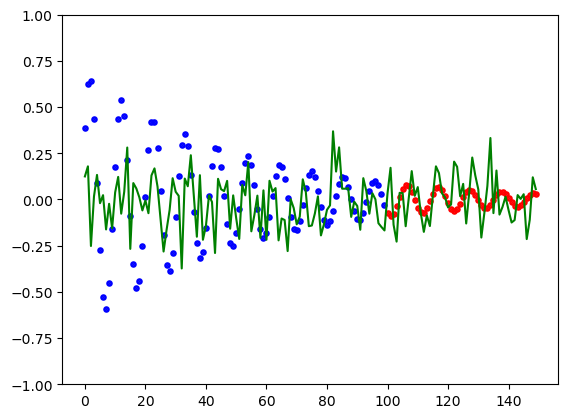

In [10]:
lossA = []
bStateA = []
for seed in seeds:
    print('seed:', seed)
    loss, bState = damping_test(seed)
    lossA.append(loss)
    bStateA.append(bState)
    
    # plot to file
    plotPNG(seed, loss, bState)

In [29]:
best_model = Sequence()
loss = 0
for bState in bStateA:
    best_model.load_state_dict(bState)
    bestPredict = best_model(dampInput, 50).detach()
    loss += criterion(bestPredict[101:], damp[101:]).item()
    
loss

C:\ProgramData\Anaconda3\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([50])) that is different to the input size (torch.Size([49, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


0.08252046769484878

In [ ]:
seeds[6]

In [11]:
bState = bStateA[0]

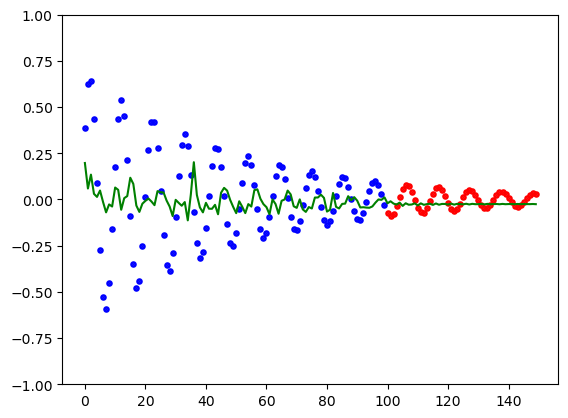

In [12]:
best_model = Sequence()
best_model.load_state_dict(bState)
bestPredict = best_model(dampInput, 50).detach()

bp = bestPredict.tolist()
ta = dampTarget.tolist()
tb = damp[len(dampInput)+1:].tolist()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

In [ ]:
# ys2 = ((torch.tensor([np.sin(_*0.5) for _ in range(151)])*0.5)).float()
ys2 = ((torch.tensor([np.sin(_*0.55)*np.exp(_*0.01) for _ in range(151)])*0.2)).float()
testInput2 = ys2[:-51]
testTarget2 = ys2[1:len(testInput)+1]

testInput2 = testInput2.reshape([len(testInput2),1])
testTarget2 = testTarget2.reshape([len(testTarget2),1])

In [ ]:
best_model = Sequence()
best_model.load_state_dict(bState)
bestPredict2 = best_model(testInput2, 50).detach()

bp2 = bestPredict2.tolist()
ta2 = testTarget2.tolist()
tb2 = ys2[len(testInput2)+1:].tolist()
plt.plot(range(len(ta2)), ta2, c='c')
plt.plot(np.array(range(len(tb2)))+len(ta2), tb2, c='pink')
plt.plot(bp2, c='g')
plt.ylim(-1,1)
plt.show()

## Save / Load

In [11]:
with open('lossA.pickle', 'wb') as f:
    pickle.dump(lossA, f)
with open('bStateA.pickle', 'wb') as f:
    pickle.dump(bStateA, f)

In [ ]:
with open('bStateA.pickle', 'rb') as f:
    bStateA = pickle.load(f)